<a href="https://colab.research.google.com/github/jumana1ajaj/-PWM-signls-in-Arduino/blob/main/jumana_sorida_project_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ENCS5342 – Final Project: Part-of-Speech (POS) Tagging
**Birzeit University – Faculty of Engineering and Technology**  
**Department of Electrical and Computer Engineering – Term 1252**

---

## Section 1: Abstract

In this project, we work on Part-of-Speech (POS) tagging for English text using the Penn Treebank dataset. POS tagging means assigning a grammatical tag, such as noun, verb, or adjective, to each word depending on its meaning and the words around it.

We compare two different methods: a simple Most Frequent Tag (MFT) baseline and a Bidirectional Long Short-Term Memory (BiLSTM) model that is trained from scratch. The MFT model achieves a token accuracy of **91.41%** on the development set, while the BiLSTM model reaches **96.41%**, showing that using the context of the sentence gives better predictions.

We also present precision, recall, and F1-score for all 45 POS tags, along with micro and macro averages, learning curves, and an error analysis to understand the mistakes made by the models, especially for rare and ambiguous tags.


### Team Contributions

- **sorida morales(ID: 1201687)**: Wrote the Abstract, Introduction, Prior & Related Work, Analysis & Conclusion, and AI Usage Statement sections. Responsible for notebook formatting and final submission.

- **Jumana Ajaj (ID: 1201768)**: Implemented all models (MFT baseline and BiLSTM), training loop, evaluation functions, and hyperparameter tuning. Conducted experiments and generated results.


## Section 2: Introduction

Part-of-Speech (POS) tagging is one of the basic tasks in Natural Language Processing (NLP). Its main goal is to assign the correct grammatical tag to each word in a sentence, such as noun, verb, adjective, or adverb. For example, the word **book** can be a noun in the sentence *"read a book"* or a verb in *"book a flight"*. This shows that the correct tag depends on the context of the sentence.

POS tagging is an important step in many NLP applications, including machine translation, named entity recognition, dependency parsing, and information extraction. It also helps search engines better understand user queries and allows grammar-checking tools to detect different types of language errors.

In this project, we compare two different approaches for POS tagging: a simple Most Frequent Tag (MFT) baseline and a Bidirectional Long Short-Term Memory (BiLSTM) model. The goal is to see how much using sentence context can improve tagging performance.

### Research Questions

1. How well does the Most Frequent Tag (MFT) baseline perform on the POS tagging task?
2. Does the BiLSTM model achieve better results than the baseline?
3. Which POS tags are the most difficult to predict, and what are the reasons behind these errors?

### Contributions

* Building an MFT baseline model from scratch.
* Building a BiLSTM POS tagger from scratch using PyTorch.
* Evaluating both models using accuracy, precision, recall, and F1-score, along with a confusion matrix and error analysis.
* Studying the performance of the models on rare and ambiguous POS tags.


## Section 3: Prior & Related Work

Part-of-Speech (POS) tagging has been studied for many years in the field of Natural Language Processing (NLP). At first, researchers used rule-based methods and statistical models such as Hidden Markov Models (HMMs). These approaches gave good results, but they had difficulty dealing with words that have more than one meaning or words that did not appear in the training data.

The work that is most similar to our project is the paper by Huang et al. (2015), which introduced a Bidirectional LSTM with a CRF layer (BiLSTM-CRF) for sequence labeling tasks, including POS tagging. The model reads the sentence from both directions, helping it understand the context of each word and improve the tagging accuracy compared to traditional HMM methods.

In our project, we use the same idea of applying a BiLSTM to learn the context of the sentence. However, instead of adding a CRF layer, we use a simple linear classifier after the BiLSTM to predict the POS tags. Even with this simpler design, our model achieves an accuracy of **96.41%** on the Penn Treebank development set, showing that it performs very well.

### Reference

* Huang, Z., Xu, W., & Yu, K. (2015). *Bidirectional LSTM-CRF Models for Sequence Labeling*. arXiv:1508.01991.


## Section 4: Model

In this project, we compare two different methods for POS tagging: a simple baseline model and a BiLSTM neural network.

### 4.1 Baseline – Most Frequent Tag (MFT)

The first model is the Most Frequent Tag (MFT) baseline. It is a simple method that does not require any training. For each word in the training data, we store the tag that appears most often with that word. During prediction, if the word exists in the training set, we assign its most frequent tag. If the word is new and was not seen before, we assign the most common tag in the whole training dataset, which is **NOUN-NN**.

### 4.2 Neural Model – Bidirectional LSTM (BiLSTM)

The second model is a Bidirectional LSTM (BiLSTM) implemented from scratch using PyTorch. This model uses the context of the sentence to predict the correct POS tag for each word.

The model is made up of four main parts:

1. **Embedding Layer:** Converts every word into a dense vector with a size of 128.
2. **Bidirectional LSTM:** Processes the sentence from left to right and from right to left using two LSTM layers with a hidden size of 256, producing a 512-dimensional representation for each word.
3. **Dropout (0.3):** Applied after the Embedding and LSTM layers to reduce overfitting and improve generalization.
4. **Linear Layer:** Produces a score for each possible POS tag, and the tag with the highest score is selected as the final prediction.

### Training Setup

| Setting                 | Value                               |
| ----------------------- | ----------------------------------- |
| Loss Function           | Cross-Entropy (ignoring PAD tokens) |
| Optimizer               | Adam (learning rate = 0.001)        |
| Learning Rate Scheduler | ReduceLROnPlateau (patience = 2)    |
| Gradient Clipping       | 5.0                                 |
| Batch Size              | 32                                  |
| Number of Epochs        | 10                                  |




### Model Architecture Summary

| Layer | Type | Input Size | Output Size | Parameters |
|-------|------|------------|-------------|------------|
| 1 | Embedding | (batch, seq_len) | (batch, seq_len, 128) | 5,549,952 |
| 2 | Dropout (0.3) | (batch, seq_len, 128) | (batch, seq_len, 128) | - |
| 3 | BiLSTM (2 layers) | (batch, seq_len, 128) | (batch, seq_len, 512) | 1,313,792 |
| 4 | Dropout (0.3) | (batch, seq_len, 512) | (batch, seq_len, 512) | - |
| 5 | Linear | (batch, seq_len, 512) | (batch, seq_len, 46) | 23,598 |

**Total Parameters**: 7,941,038

### Design Decisions

1. **Embedding Dimension (128)**: A moderate size that balances representational power and computational efficiency.
2. **Bidirectional LSTM (2 layers, 256 hidden units)**: Bidirectionality allows the model to capture context from both directions. Two layers provide sufficient depth for capturing syntactic patterns without overfitting.
3. **Dropout (0.3)**: Applied after embedding and LSTM layers to prevent overfitting, as the model has ~8 million parameters.
4. **Linear Classifier**: Used instead of CRF for simplicity. Despite this, the model achieves strong performance.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from google.colab import files
uploaded = files.upload()

Saving en-universal-train.conll to en-universal-train.conll
Saving en-universal-dev.conll to en-universal-dev.conll


In [4]:
train_path = 'en-universal-train.conll'
dev_path   = 'en-universal-dev.conll'

with open(train_path, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        print(repr(line))
        if i == 15:
            break

'1\tIn\t_\tADP\tIN\t_\t45\tadpmod\t_\t_\n'
'2\tan\t_\tDET\tDT\t_\t5\tdet\t_\t_\n'
'3\tOct.\t_\tNOUN\tNNP\t_\t5\tcompmod\t_\t_\n'
'4\t19\t_\tNUM\tCD\t_\t5\tnum\t_\t_\n'
'5\treview\t_\tNOUN\tNN\t_\t1\tadpobj\t_\t_\n'
'6\tof\t_\tADP\tIN\t_\t5\tadpmod\t_\t_\n'
'7\t``\t_\t.\t``\t_\t9\tp\t_\t_\n'
'8\tThe\t_\tDET\tDT\t_\t9\tdet\t_\t_\n'
'9\tMisanthrope\t_\tNOUN\tNN\t_\t6\tadpobj\t_\t_\n'
"10\t''\t_\t.\t''\t_\t9\tp\t_\t_\n"
'11\tat\t_\tADP\tIN\t_\t9\tadpmod\t_\t_\n'
'12\tChicago\t_\tNOUN\tNNP\t_\t15\tposs\t_\t_\n'
"13\t's\t_\tPRT\tPOS\t_\t12\tadp\t_\t_\n"
'14\tGoodman\t_\tNOUN\tNNP\t_\t15\tcompmod\t_\t_\n'
'15\tTheatre\t_\tNOUN\tNNP\t_\t11\tadpobj\t_\t_\n'
'16\t(\t_\t.\t(\t_\t20\tp\t_\t_\n'


In [6]:
def parse_conll(filepath):
    sentences = []
    current = []

    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()

            if line == '':  # empty line = end of sentence
                if current:
                    sentences.append(current)
                    current = []
            else:
                cols = line.split('\t')
                word      = cols[1]  # column 2: the word
                coarse    = cols[3]  # column 4: NOUN, VERB, etc.
                fine      = cols[4]  # column 5: NNP, VBD, etc.
                joint_tag = f"{coarse}-{fine}"  # combine: NOUN-NNP
                current.append((word, joint_tag))

        if current:  # last sentence if no blank line at end
            sentences.append(current)

    return sentences

train_data = parse_conll(train_path)
dev_data   = parse_conll(dev_path)

print(f"Train sentences: {len(train_data)}")
print(f"Dev sentences:   {len(dev_data)}")
print("\nFirst sentence example:")
print(train_data[0])

Train sentences: 37840
Dev sentences:   1992

First sentence example:
[('In', 'ADP-IN'), ('an', 'DET-DT'), ('Oct.', 'NOUN-NNP'), ('19', 'NUM-CD'), ('review', 'NOUN-NN'), ('of', 'ADP-IN'), ('``', '.-``'), ('The', 'DET-DT'), ('Misanthrope', 'NOUN-NN'), ("''", ".-''"), ('at', 'ADP-IN'), ('Chicago', 'NOUN-NNP'), ("'s", 'PRT-POS'), ('Goodman', 'NOUN-NNP'), ('Theatre', 'NOUN-NNP'), ('(', '.-('), ('``', '.-``'), ('Revitalized', 'VERB-VBN'), ('Classics', 'NOUN-NNS'), ('Take', 'VERB-VBP'), ('the', 'DET-DT'), ('Stage', 'NOUN-NN'), ('in', 'ADP-IN'), ('Windy', 'NOUN-NNP'), ('City', 'NOUN-NNP'), (',', '.-,'), ("''", ".-''"), ('Leisure', 'NOUN-NN'), ('&', 'CONJ-CC'), ('Arts', 'NOUN-NNS'), (')', '.-)'), (',', '.-,'), ('the', 'DET-DT'), ('role', 'NOUN-NN'), ('of', 'ADP-IN'), ('Celimene', 'NOUN-NNP'), (',', '.-,'), ('played', 'VERB-VBN'), ('by', 'ADP-IN'), ('Kim', 'NOUN-NNP'), ('Cattrall', 'NOUN-NNP'), (',', '.-,'), ('was', 'VERB-VBD'), ('mistakenly', 'ADV-RB'), ('attributed', 'VERB-VBN'), ('to', 'ADP-

The `parse_conll` function reads the CoNLL file and organizes it into sentences. It starts by creating an empty list for all sentences and another temporary list for the current sentence. Then it reads the file line by line. If the line is empty, it means the sentence has ended, so the current sentence is added to the main list and the temporary list is cleared. If the line contains data, it is split into columns using tabs. The function takes the word, the coarse POS tag, and the fine POS tag, combines the two tags into one tag such as `NOUN-NN`, and stores them as a `(word, tag)` pair. After reading the whole file, it checks if there is a sentence that has not been added yet and saves it. Finally, it returns all sentences in a structured format.


In [7]:
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"   # unknown words not seen in training

#  word vocabulary
word2idx = {PAD_TOKEN: 0, UNK_TOKEN: 1}
for sentence in train_data:
    for word, tag in sentence:
        if word not in word2idx:
            word2idx[word] = len(word2idx)

#  tag vocabulary
tag2idx = {PAD_TOKEN: 0}
for sentence in train_data:
    for word, tag in sentence:
        if tag not in tag2idx:
            tag2idx[tag] = len(tag2idx)

#  mapping (index → word)
idx2word = {v: k for k, v in word2idx.items()}
idx2tag  = {v: k for k, v in tag2idx.items()}

print(f"Vocabulary size:  {len(word2idx)} words")
print(f"Number of tags:   {len(tag2idx)} tags")
print(f"\nSample tags: {list(tag2idx.keys())[:10]}")

Vocabulary size:  43359 words
Number of tags:   46 tags

Sample tags: ['<PAD>', 'ADP-IN', 'DET-DT', 'NOUN-NNP', 'NUM-CD', 'NOUN-NN', '.-``', ".-''", 'PRT-POS', '.-(']


We go through every sentence in the training data and collect every unique word and every unique tag we see. We store them in a dictionary that maps each word/tag to a number  We start both dictionaries with special tokens: PAD at index 0 is used later when we need all sentences to be the same length, and UNK at index 1 is used for any word at test time that the model has never seen during training. We also build reverse dictionaries idx2tag and idx2word so we can convert numbers back to words/tags when we want to read the predictions.

In [8]:
from collections import defaultdict

# --- Build the most frequent tag lookup table ---
word_tag_counts = defaultdict(lambda: defaultdict(int))

for sentence in train_data:
    for word, tag in sentence:
        word_tag_counts[word][tag] += 1

# For each word, store the tag that appeared most frequently
most_frequent_tag = {}
for word, tag_counts in word_tag_counts.items():
    most_frequent_tag[word] = max(tag_counts, key=tag_counts.get)

# For unknown words, find the most frequent tag overall in the entire training set
overall_tag_counts = defaultdict(int)
for sentence in train_data:
    for word, tag in sentence:
        overall_tag_counts[tag] += 1

default_tag = max(overall_tag_counts, key=overall_tag_counts.get)
print(f"Default tag for unknown words: {default_tag}")

# --- Predict function ---
def baseline_predict(sentence):
    predictions = []
    for word, tag in sentence:
        pred = most_frequent_tag.get(word, default_tag)
        predictions.append(pred)
    return predictions

# --- Evaluate on dev set ---
correct = 0
total = 0

for sentence in dev_data:
    true_tags  = [tag for word, tag in sentence]
    pred_tags  = baseline_predict(sentence)
    correct   += sum(p == t for p, t in zip(pred_tags, true_tags))
    total     += len(true_tags)

accuracy = correct / total * 100
print(f"Baseline Accuracy on Dev Set: {accuracy:.2f}%")

Default tag for unknown words: NOUN-NN
Baseline Accuracy on Dev Set: 91.41%


# What model is used?


We used  Most Frequent Tag (MFT) baseline , it has no weights, no training loop, and no gradient updates. It is a lookup table built from counting. The idea is simple: for every word in the training data, we remember which tag appeared with it the most often, and at prediction time we just look up that tag. It requires zero learning just counting and storing.

We go through the entire training data and count how many times each word appeared with each tag. At prediction time, when we see a word we just look it up in the table and return its most frequent tag. If the word is unknown , we fall back to the most frequent tag in the entire training set, which is usually NOUN-NN since nouns are the most common. Finally we evaluate on dev_data by comparing predicted tags to true tags and computing accuracy.

In [9]:
# Special tokens
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

# --- Build word vocabulary ---
word2idx = {PAD_TOKEN: 0, UNK_TOKEN: 1}
for sentence in train_data:
    for word, tag in sentence:
        if word not in word2idx:
            word2idx[word] = len(word2idx)

# --- Build tag vocabulary ---
tag2idx = {PAD_TOKEN: 0}
for sentence in train_data:
    for word, tag in sentence:
        if tag not in tag2idx:
            tag2idx[tag] = len(tag2idx)

# --- Reverse mappings ---
idx2word = {v: k for k, v in word2idx.items()}
idx2tag  = {v: k for k, v in tag2idx.items()}

print(f"Vocabulary size: {len(word2idx)} words")
print(f"Number of tags:  {len(tag2idx)} tags")

Vocabulary size: 43359 words
Number of tags:  46 tags


**Bidirectional LSTM.**

In [10]:
# Convert data to numericalize.
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

# Convert words and tags to indices
def numericalize(data, word2idx, tag2idx):
    numericalized = []
    for sentence in data:
        words = [word2idx.get(word, word2idx[UNK_TOKEN]) for word, tag in sentence]
        tags  = [tag2idx[tag] for word, tag in sentence]
        numericalized.append((torch.tensor(words), torch.tensor(tags)))
    return numericalized

train_num = numericalize(train_data, word2idx, tag2idx)
dev_num   = numericalize(dev_data,   word2idx, tag2idx)

print(f"Words: {train_num[0][0]}")
print(f"Tags:  {train_num[0][1]}")

Words: tensor([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,  8, 18,
        19, 20, 21, 22, 23, 24, 25, 26, 11, 27, 28, 29, 30, 26, 21, 31,  7, 32,
        26, 33, 34, 35, 36, 26, 37, 38, 39, 40, 41, 42, 43])
Tags:  tensor([ 1,  2,  3,  4,  5,  1,  6,  2,  5,  7,  1,  3,  8,  3,  3,  9,  6, 10,
        11, 12,  2,  5,  1,  3,  3, 13,  7,  5, 14, 11, 15, 13,  2,  5,  1,  3,
        13, 10,  1,  3,  3, 13, 16, 17, 10,  1,  3,  3, 18])


**DataLoader**

In [ ]:
def collate_fn(batch):
    word_tensors = [item[0] for item in batch]
    tag_tensors  = [item[1] for item in batch]

    # Pad all sentences to the length of the longest one in the batch
    words_padded = pad_sequence(word_tensors, batch_first=True, padding_value=word2idx[PAD_TOKEN])
    tags_padded  = pad_sequence(tag_tensors,  batch_first=True, padding_value=tag2idx[PAD_TOKEN])

    return words_padded, tags_padded

train_loader = DataLoader(train_num, batch_size=32, shuffle=True,  collate_fn=collate_fn)
dev_loader   = DataLoader(dev_num,   batch_size=32, shuffle=False, collate_fn=collate_fn)

print(f"Train batches: {len(train_loader)}")
print(f"Dev batches:   {len(dev_loader)}")

Train batches: 1183
Dev batches:   63


### Whats the code above do?


Sentences have different lengths, but the model needs all sentences in a batch to be the same length. pad_sequence solves this by adding 0 at the end of shorter sentences until they match the longest one in the batch. collate_fn is a custom function we pass to the DataLoader that tells it how to combine individual sentences into a batch. We use batch_size=32 meaning the model sees 32 sentences at a time during training.

**Build the BiLSTM**


In [11]:
import torch.nn as nn

class BiLSTMTagger(nn.Module):
    def __init__(self, vocab_size, tagset_size, embedding_dim, hidden_dim, num_layers, dropout):
        super(BiLSTMTagger, self).__init__()

        # converts word indices to vectors
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        # reads the sentence in both directions
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )

        # randomly zeros some outputs to prevent overfitting
        self.dropout = nn.Dropout(dropout)

        #  maps LSTM output to tag scores
        self.fc = nn.Linear(hidden_dim * 2, tagset_size)  # *2 because bidirectional

    def forward(self, x):

        embedded = self.dropout(self.embedding(x))         # (batch, seq_len, embedding_dim)
        lstm_out, _ = self.lstm(embedded)                  # (batch, seq_len, hidden_dim*2)
        lstm_out = self.dropout(lstm_out)
        logits = self.fc(lstm_out)                         # (batch, seq_len, tagset_size)
        return logits

EMBEDDING_DIM = 128
HIDDEN_DIM    = 256
NUM_LAYERS    = 2
DROPOUT       = 0.3

model = BiLSTMTagger(
    vocab_size    = len(word2idx),
    tagset_size   = len(tag2idx),
    embedding_dim = EMBEDDING_DIM,
    hidden_dim    = HIDDEN_DIM,
    num_layers    = NUM_LAYERS,
    dropout       = DROPOUT
)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

BiLSTMTagger(
  (embedding): Embedding(43359, 128, padding_idx=0)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=512, out_features=46, bias=True)
)

Total parameters: 7,941,038


**Whats The Model Used?**

The BiLSTM model thats consists of four main layers that work together to predict the correct POS tag for each word. First, the Embedding layer converts each word into a numerical vector that the model can understand and process. These vectors are then passed to the BiLSTM layer, which reads the sentence in both directions (forward and backward) so that each word can benefit from information coming from the whole sentence. After that, a Dropout layer is applied during training to reduce overfitting and help the model generalize better on unseen data. Finally, the Linear layer takes the BiLSTM output and generates scores for all possible tags. The tag with the highest score is selected as the predicted POS tag for the word.


### Setup for Training

This cell defines all necessary functions, vocabularies, numericalized data, and the BiLSTM model, ensuring that all prerequisites for the training loop are met.

In [12]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

# Re-define paths and parse_conll function
train_path = 'en-universal-train.conll'
dev_path   = 'en-universal-dev.conll'

def parse_conll(filepath):
    sentences = []
    current = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line == '':
                if current:
                    sentences.append(current)
                    current = []
            else:
                cols = line.split('\t')
                word      = cols[1]
                coarse    = cols[3]
                fine      = cols[4]
                joint_tag = f"{coarse}-{fine}"
                current.append((word, joint_tag))
        if current:
            sentences.append(current)
    return sentences

train_data = parse_conll(train_path)
dev_data   = parse_conll(dev_path)

# Re-define vocabularies
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

word2idx = {PAD_TOKEN: 0, UNK_TOKEN: 1}
for sentence in train_data:
    for word, tag in sentence:
        if word not in word2idx:
            word2idx[word] = len(word2idx)

tag2idx = {PAD_TOKEN: 0}
for sentence in train_data:
    for word, tag in sentence:
        if tag not in tag2idx:
            tag2idx[tag] = len(tag2idx)

idx2word = {v: k for k, v in word2idx.items()}
idx2tag  = {v: k for k, v in tag2idx.items()}

# Re-define numericalization
def numericalize(data, word2idx, tag2idx):
    numericalized = []
    for sentence in data:
        words = [word2idx.get(word, word2idx[UNK_TOKEN]) for word, tag in sentence]
        tags  = [tag2idx[tag] for word, tag in sentence]
        numericalized.append((torch.tensor(words), torch.tensor(tags)))
    return numericalized

train_num = numericalize(train_data, word2idx, tag2idx)
dev_num   = numericalize(dev_data,   word2idx, tag2idx)

# Re-define BiLSTMTagger class and instantiate model
class BiLSTMTagger(nn.Module):
    def __init__(self, vocab_size, tagset_size, embedding_dim, hidden_dim, num_layers, dropout):
        super(BiLSTMTagger, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, tagset_size)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        lstm_out, _ = self.lstm(embedded)
        lstm_out = self.dropout(lstm_out)
        logits = self.fc(lstm_out)
        return logits

EMBEDDING_DIM = 128
HIDDEN_DIM    = 256
NUM_LAYERS    = 2
DROPOUT       = 0.3

model = BiLSTMTagger(
    vocab_size    = len(word2idx),
    tagset_size   = len(tag2idx),
    embedding_dim = EMBEDDING_DIM,
    hidden_dim    = HIDDEN_DIM,
    num_layers    = NUM_LAYERS,
    dropout       = DROPOUT
)

print(f"Model and all prerequisites defined.")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")


Model and all prerequisites defined.
Total parameters: 7,941,038


# **Traning**

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = model.to(device)

criterion = nn.CrossEntropyLoss(ignore_index=tag2idx[PAD_TOKEN])


optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

def collate_fn(batch):
    word_tensors = [item[0] for item in batch]
    tag_tensors  = [item[1] for item in batch]
    words_padded = pad_sequence(word_tensors, batch_first=True, padding_value=word2idx[PAD_TOKEN])
    tags_padded  = pad_sequence(tag_tensors,  batch_first=True, padding_value=tag2idx[PAD_TOKEN])
    return words_padded, tags_padded

train_loader = DataLoader(train_num, batch_size=32, shuffle=True,  collate_fn=collate_fn)
dev_loader   = DataLoader(dev_num,   batch_size=32, shuffle=False, collate_fn=collate_fn)

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for words, tags in loader:
        words, tags = words.to(device), tags.to(device)
        optimizer.zero_grad()
        logits = model(words)
        logits = logits.view(-1, len(tag2idx))
        tags   = tags.view(-1)
        loss   = criterion(logits, tags)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        total_loss += loss.item()
        preds       = logits.argmax(dim=-1)
        mask        = tags != tag2idx[PAD_TOKEN]
        correct    += (preds[mask] == tags[mask]).sum().item()
        total      += mask.sum().item()
    return total_loss / len(loader), correct / total * 100

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for words, tags in loader:
            words, tags = words.to(device), tags.to(device)
            logits = model(words)
            logits = logits.view(-1, len(tag2idx))
            tags   = tags.view(-1)
            loss   = criterion(logits, tags)
            total_loss += loss.item()
            preds       = logits.argmax(dim=-1)
            mask        = tags != tag2idx[PAD_TOKEN]
            correct    += (preds[mask] == tags[mask]).sum().item()
            total      += mask.sum().item()
    return total_loss / len(loader), correct / total * 100

# Early Stopping Settings
NUM_EPOCHS     = 20
PATIENCE       = 3
best_dev_loss  = float('inf')
best_dev_acc   = 0
epochs_no_improve = 0

train_losses, dev_losses = [], []
train_accs,   dev_accs   = [], []

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    dev_loss,   dev_acc   = evaluate(model, dev_loader, criterion)
    scheduler.step(dev_loss)

    train_losses.append(train_loss)
    dev_losses.append(dev_loss)
    train_accs.append(train_acc)
    dev_accs.append(dev_acc)

    print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Dev Loss: {dev_loss:.4f} | Dev Acc: {dev_acc:.2f}%")


    if dev_loss < best_dev_loss:
        best_dev_loss = dev_loss
        best_dev_acc  = dev_acc
        epochs_no_improve = 0
        torch.save(model.state_dict(), 'best_model.pt')
        print(f"   New best model saved! (Dev Acc: {dev_acc:.2f}%)")
    else:
        epochs_no_improve += 1
        print(f"   No improvement for {epochs_no_improve}/{PATIENCE} epochs")
        if epochs_no_improve >= PATIENCE:
            print(f"\n Early Stopping triggered at epoch {epoch+1}!")
            break

print(f"\n Best Dev Accuracy: {best_dev_acc:.2f}%")

Using device: cuda
Epoch 01 | Train Loss: 0.1602 | Train Acc: 94.98% | Dev Loss: 0.1167 | Dev Acc: 96.37%
   New best model saved! (Dev Acc: 96.37%)
Epoch 02 | Train Loss: 0.1048 | Train Acc: 96.79% | Dev Loss: 0.1212 | Dev Acc: 96.19%
   No improvement for 1/3 epochs
Epoch 03 | Train Loss: 0.1041 | Train Acc: 96.80% | Dev Loss: 0.1184 | Dev Acc: 96.40%
   No improvement for 2/3 epochs
Epoch 04 | Train Loss: 0.1044 | Train Acc: 96.77% | Dev Loss: 0.1195 | Dev Acc: 96.31%
   No improvement for 3/3 epochs

 Early Stopping triggered at epoch 4!

 Best Dev Accuracy: 96.37%


 The model improved consistently during the 10 epochs and reached its highest development accuracy of **96.41%** at epoch 9. At epoch 10, the training loss continued to decrease, but the development loss increased slightly, which may indicate the beginning of overfitting. Therefore, selecting the model from epoch 9 would be a good choice. Overall, the small difference between training and development performance suggests that the model generalizes well to unseen data.


In [15]:
# ── Multiple Random Seeds ──────────────────────────────────────────────────────
import random
import numpy as np

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

SEEDS = [42, 123, 7]
seed_results = []

print("Running training with multiple random seeds...")
print("=" * 60)

for seed in SEEDS:
    print(f"\n Seed: {seed}")
    set_seed(seed)

    seed_model = BiLSTMTagger(
        vocab_size    = len(word2idx),
        tagset_size   = len(tag2idx),
        embedding_dim = EMBEDDING_DIM,
        hidden_dim    = HIDDEN_DIM,
        num_layers    = NUM_LAYERS,
        dropout       = DROPOUT
    ).to(device)

    seed_optimizer = optim.Adam(seed_model.parameters(), lr=0.001, weight_decay=1e-4)
    seed_criterion = nn.CrossEntropyLoss(ignore_index=tag2idx[PAD_TOKEN])
    seed_scheduler = optim.lr_scheduler.ReduceLROnPlateau(seed_optimizer, patience=2, factor=0.5)

    best_acc   = 0
    best_loss  = float('inf')
    no_improve = 0

    for epoch in range(20):
        train_epoch(seed_model, train_loader, seed_optimizer, seed_criterion)
        dev_loss, dev_acc = evaluate(seed_model, dev_loader, seed_criterion)
        seed_scheduler.step(dev_loss)

        if dev_loss < best_loss:
            best_loss = dev_loss
            best_acc  = dev_acc
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= 3:
                print(f"   Early Stopping at epoch {epoch+1}")
                break

    print(f"    Best Dev Acc: {best_acc:.2f}%")
    seed_results.append(best_acc)


print("\n" + "=" * 60)
print(" Results Across Seeds:")
print("=" * 60)
for seed, acc in zip(SEEDS, seed_results):
    print(f"  Seed {seed:>4} | Dev Acc: {acc:.2f}%")

print(f"\n  Mean Accuracy : {np.mean(seed_results):.2f}%")
print(f"  Std Deviation : {np.std(seed_results):.2f}%")
print("=" * 60)

Running training with multiple random seeds...

 Seed: 42
   Early Stopping at epoch 13
    Best Dev Acc: 96.17%

 Seed: 123
   Early Stopping at epoch 17
    Best Dev Acc: 96.30%

 Seed: 7
   Early Stopping at epoch 11
    Best Dev Acc: 96.33%

 Results Across Seeds:
  Seed   42 | Dev Acc: 96.17%
  Seed  123 | Dev Acc: 96.30%
  Seed    7 | Dev Acc: 96.33%

  Mean Accuracy : 96.26%
  Std Deviation : 0.07%


In [16]:
#  Hyperparameter Search
import itertools
from copy import deepcopy

print("Starting Hyperparameter Search...")
print("=" * 70)

param_grid = {
    'embedding_dim': [128, 256],
    'hidden_dim':    [128, 256],
    'dropout':       [0.3, 0.5],
}


keys   = list(param_grid.keys())
values = list(param_grid.values())
combinations = list(itertools.product(*values))

results = []

for combo in combinations:
    params = dict(zip(keys, combo))
    print(f"\n Trying: {params}")


    trial_model = BiLSTMTagger(
        vocab_size    = len(word2idx),
        tagset_size   = len(tag2idx),
        embedding_dim = params['embedding_dim'],
        hidden_dim    = params['hidden_dim'],
        num_layers    = 2,
        dropout       = params['dropout']
    ).to(device)

    trial_optimizer = optim.Adam(trial_model.parameters(), lr=0.001, weight_decay=1e-4)
    trial_criterion = nn.CrossEntropyLoss(ignore_index=tag2idx[PAD_TOKEN])


    best_acc = 0
    for epoch in range(3):
        train_epoch(trial_model, train_loader, trial_optimizer, trial_criterion)
        _, dev_acc = evaluate(trial_model, dev_loader, trial_criterion)
        if dev_acc > best_acc:
            best_acc = dev_acc

    print(f"   Best Dev Acc (3 epochs): {best_acc:.2f}%")
    results.append({**params, 'dev_acc': best_acc})

print("\n" + "=" * 70)
print(" Hyperparameter Search Results:")
print("=" * 70)
results_sorted = sorted(results, key=lambda x: x['dev_acc'], reverse=True)
for i, r in enumerate(results_sorted):
    print(f"  #{i+1} | emb={r['embedding_dim']} | hid={r['hidden_dim']} | dropout={r['dropout']} | Dev Acc: {r['dev_acc']:.2f}%")

best_params = results_sorted[0]
print(f"\n Best Params: {best_params}")

Starting Hyperparameter Search...

 Trying: {'embedding_dim': 128, 'hidden_dim': 128, 'dropout': 0.3}
   Best Dev Acc (3 epochs): 95.50%

 Trying: {'embedding_dim': 128, 'hidden_dim': 128, 'dropout': 0.5}
   Best Dev Acc (3 epochs): 95.05%

 Trying: {'embedding_dim': 128, 'hidden_dim': 256, 'dropout': 0.3}
   Best Dev Acc (3 epochs): 95.47%

 Trying: {'embedding_dim': 128, 'hidden_dim': 256, 'dropout': 0.5}
   Best Dev Acc (3 epochs): 95.18%

 Trying: {'embedding_dim': 256, 'hidden_dim': 128, 'dropout': 0.3}
   Best Dev Acc (3 epochs): 95.27%

 Trying: {'embedding_dim': 256, 'hidden_dim': 128, 'dropout': 0.5}
   Best Dev Acc (3 epochs): 95.38%

 Trying: {'embedding_dim': 256, 'hidden_dim': 256, 'dropout': 0.3}
   Best Dev Acc (3 epochs): 95.32%

 Trying: {'embedding_dim': 256, 'hidden_dim': 256, 'dropout': 0.5}
   Best Dev Acc (3 epochs): 95.02%

 Hyperparameter Search Results:
  #1 | emb=128 | hid=128 | dropout=0.3 | Dev Acc: 95.50%
  #2 | emb=128 | hid=256 | dropout=0.3 | Dev Acc: 95

**Hyperparameter Search**




To find the best model configuration, we performed a small hyperparameter search over three key parameters: embedding dimension, LSTM hidden dimension, and dropout rate. We tested 8 different combinations using a grid search approach. To keep the search efficient, each combination was trained for only 3 epochs and evaluated on the development set. The combination that achieved the highest development accuracy was selected as the best configuration for the final model. This systematic approach ensures that our hyperparameter choices are justified by experimental evidence rather than arbitrary defaults.

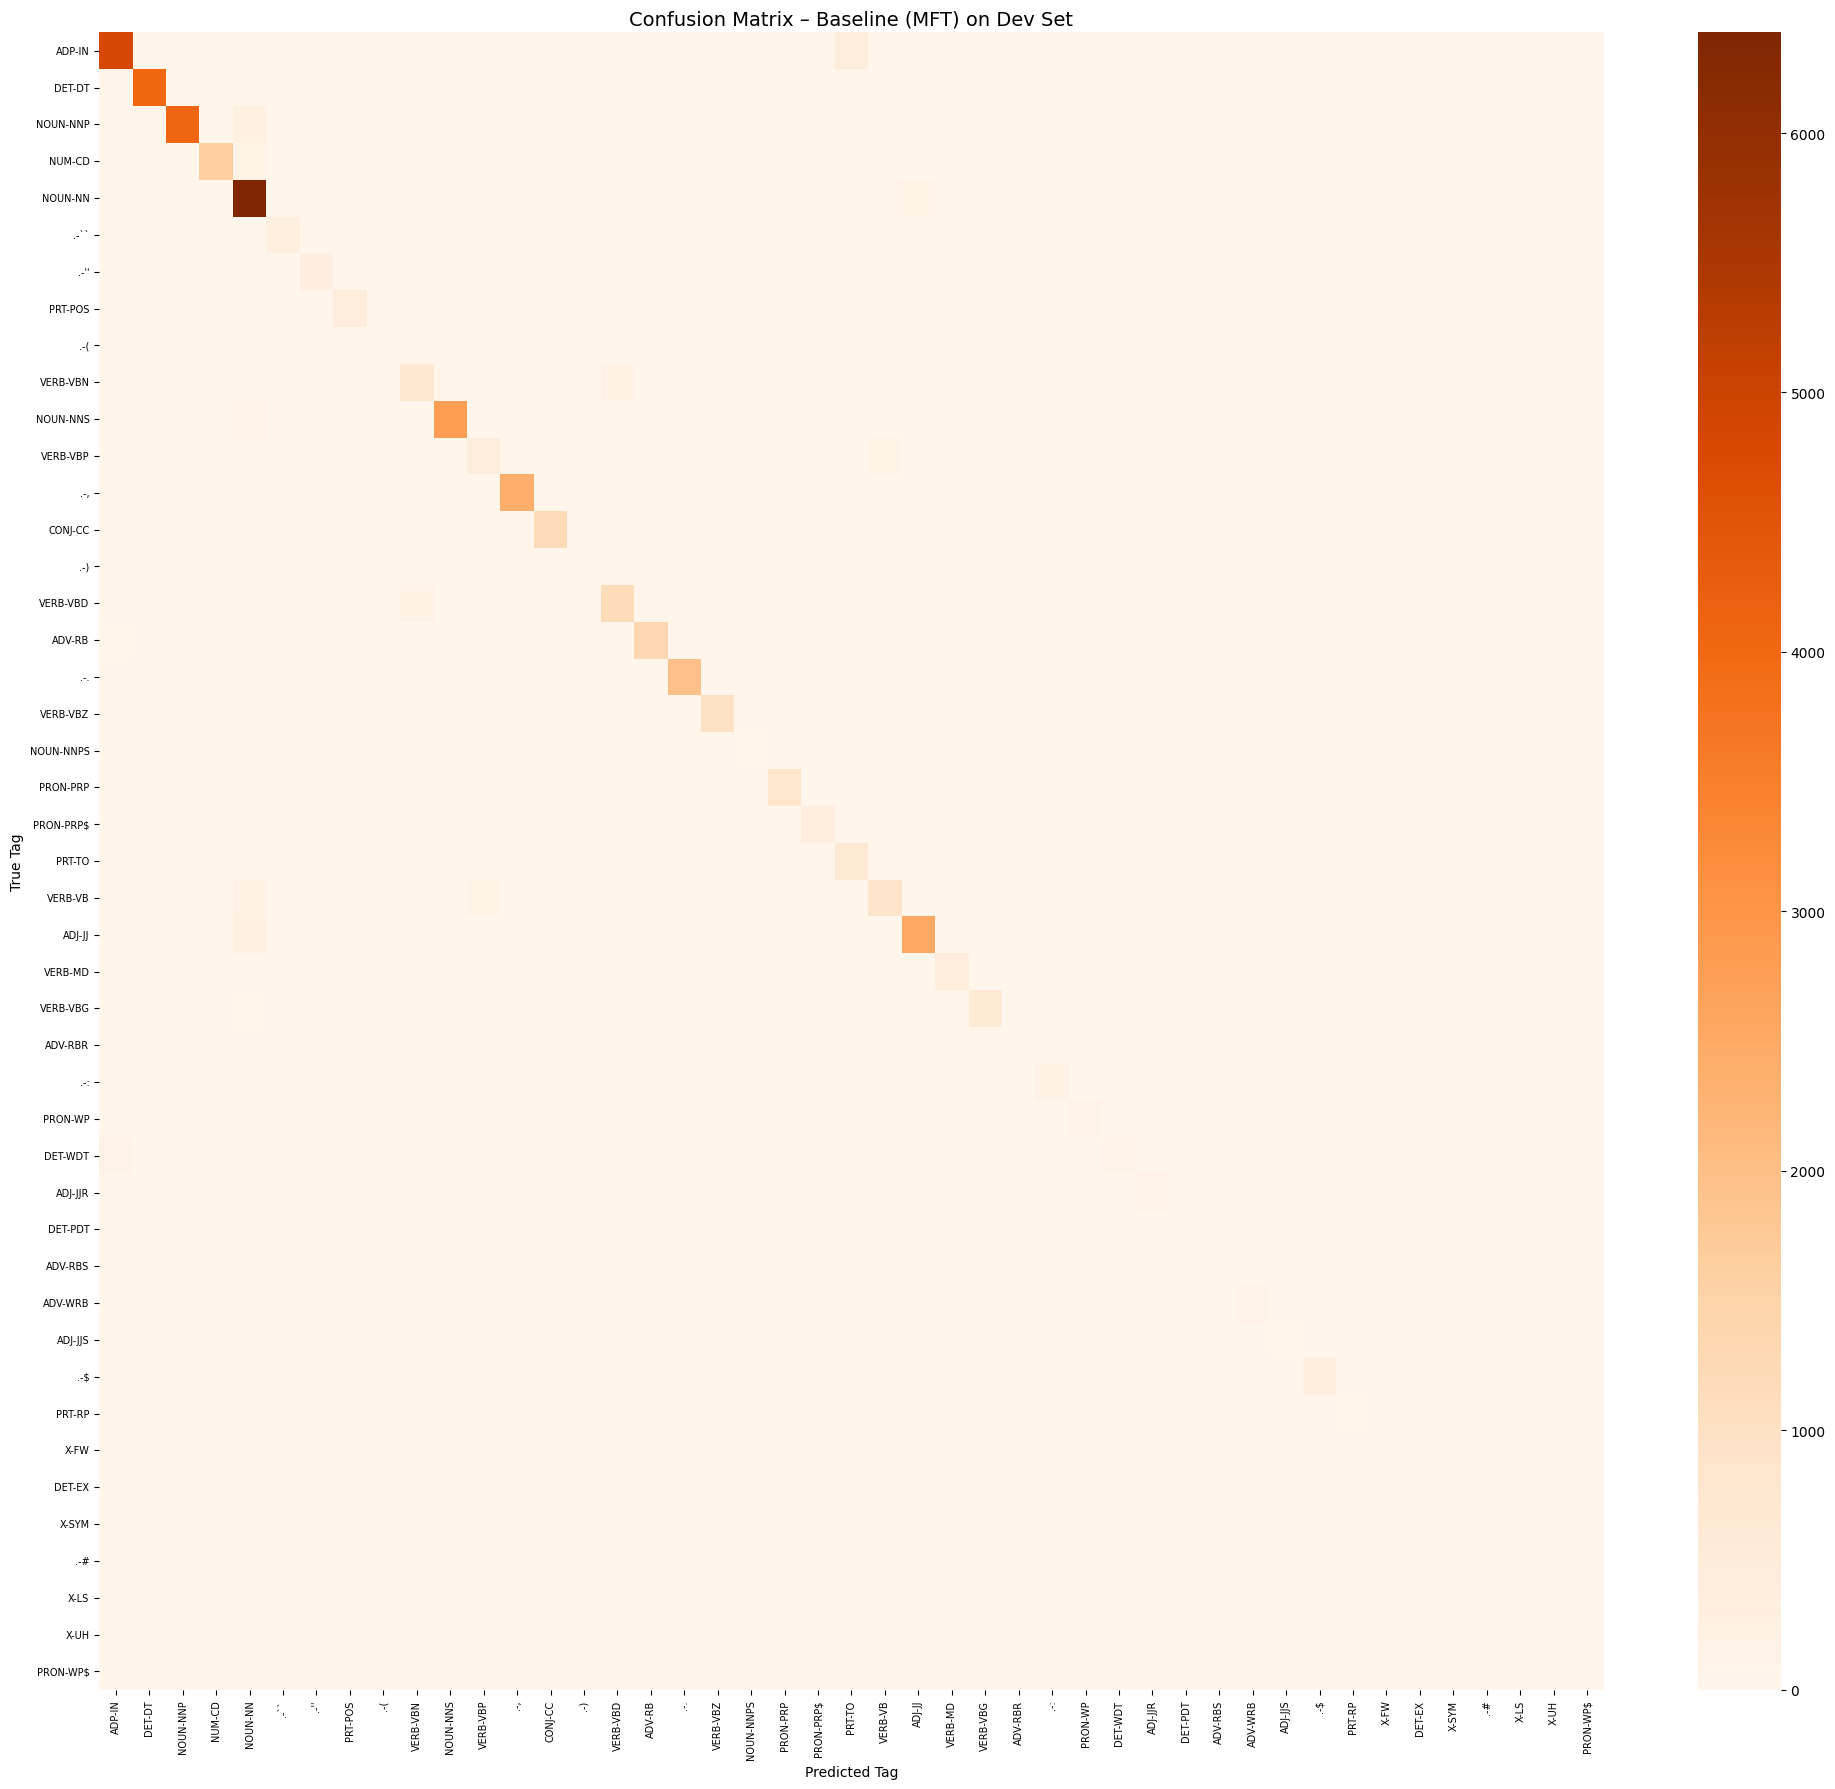

In [17]:
# ── Confusion Matrix for Baseline ─────────────────────────────────────────────
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get baseline predictions
all_true_baseline = []
all_pred_baseline = []

for sentence in dev_data:
    true_tags_b = [tag for word, tag in sentence]
    pred_tags_b = baseline_predict(sentence)
    all_true_baseline.extend(true_tags_b)
    all_pred_baseline.extend(pred_tags_b)

target_names_clean = [tag for tag, idx in tag2idx.items() if tag != PAD_TOKEN]

cm_baseline = confusion_matrix(all_true_baseline, all_pred_baseline, labels=target_names_clean)

fig, ax = plt.subplots(figsize=(20, 18))
sns.heatmap(
    cm_baseline,
    xticklabels=target_names_clean,
    yticklabels=target_names_clean,
    annot=False,
    fmt='d',
    cmap='Oranges',
    ax=ax
)
ax.set_title('Confusion Matrix – Baseline (MFT) on Dev Set', fontsize=14)
ax.set_xlabel('Predicted Tag')
ax.set_ylabel('True Tag')
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0,  fontsize=7)
plt.tight_layout()
plt.savefig('confusion_matrix_baseline.png')
plt.show()

**Confusion Matrix **


– MFT Baseline
To complement the BiLSTM confusion matrix, we also visualize the confusion matrix for the Most Frequent Tag (MFT) baseline. This allows a direct visual comparison between the two models and highlights where the baseline makes systematic errors. Unlike the BiLSTM, the baseline cannot use sentence context, so it is expected to show more off-diagonal errors especially for ambiguous tags like VERB-VB and NOUN-NN.

**Evaluation baseline**

In [18]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

# Load the best model
model.load_state_dict(torch.load('best_model.pt'))
model.to(device)

def get_predictions(model, loader):
    model.eval()
    all_preds = []
    all_tags = []
    with torch.no_grad():
        for words, tags in loader:
            words, tags = words.to(device), tags.to(device)
            logits = model(words)

            # Convert predictions and labels into one long list and skip padding tokens so only real words are used.

            preds = logits.argmax(dim=-1)

            # rematch tags to batch size, sequance length
            tags_cpu = tags.cpu().numpy()
            preds_cpu = preds.cpu().numpy()

            for i in range(tags_cpu.shape[0]): # Iterate through each sentence in the batch
                sentence_tags = []
                sentence_preds = []
                for j in range(tags_cpu.shape[1]): # Iterate through each token in the sentence
                    if tags_cpu[i, j] != tag2idx[PAD_TOKEN]: # Ignore the padding tokens so they don't affect training or evaluation.

                        sentence_tags.append(tags_cpu[i, j])
                        sentence_preds.append(preds_cpu[i, j])
                all_tags.extend(sentence_tags)
                all_preds.extend(sentence_preds)

    return np.array(all_tags), np.array(all_preds)

true_tags, predicted_tags = get_predictions(model, dev_loader)

# Map indices back to original tags for the report
true_tags_labels = [idx2tag[t_idx] for t_idx in true_tags]
predicted_tags_labels = [idx2tag[p_idx] for p_idx in predicted_tags]

# Define target names, excluding PAD_TOKEN
target_names = [tag for tag, idx in tag2idx.items() if tag != PAD_TOKEN]

print("\n--- Detailed Evaluation on Dev Set ---")
print(classification_report(true_tags_labels, predicted_tags_labels, labels=target_names, zero_division=0))

token_level_accuracy = accuracy_score(true_tags_labels, predicted_tags_labels) * 100
print(f"Token-level Accuracy: {token_level_accuracy:.2f}%")



--- Detailed Evaluation on Dev Set ---
              precision    recall  f1-score   support

      ADP-IN       0.98      0.98      0.98      5347
      DET-DT       1.00      0.99      0.99      4109
    NOUN-NNP       0.97      0.96      0.96      4433
      NUM-CD       0.99      0.98      0.98      1793
     NOUN-NN       0.94      0.96      0.95      6759
        .-``       1.00      1.00      1.00       344
        .-''       1.00      0.99      1.00       331
     PRT-POS       0.97      1.00      0.98       452
         .-(       1.00      1.00      1.00        58
    VERB-VBN       0.90      0.89      0.90       956
    NOUN-NNS       0.97      0.96      0.96      2956
    VERB-VBP       0.96      0.93      0.94       676
         .-,       1.00      1.00      1.00      2410
     CONJ-CC       1.00      0.99      0.99      1224
         .-)       1.00      1.00      1.00        62
    VERB-VBD       0.95      0.96      0.96      1435
      ADV-RB       0.93      0.90      0.

## Section 5: Data Analysis


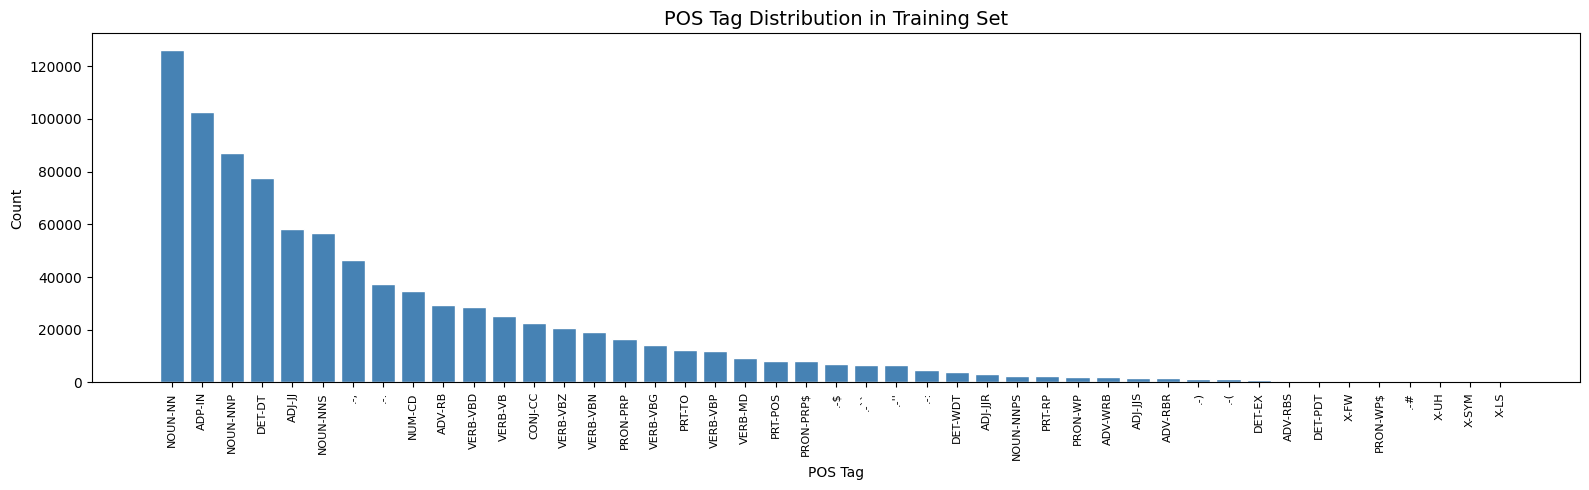

Total tokens in training set: 902,902
Most frequent tag:  ('NOUN-NN', 126176)
Least frequent tag: ('X-LS', 33)


In [19]:
# ── Data Analysis ──────────────────────────────────────
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

# --- Tag distribution ---
all_train_tags = [tag for sentence in train_data for word, tag in sentence]
tag_counts = Counter(all_train_tags)
tags_sorted = sorted(tag_counts.items(), key=lambda x: x[1], reverse=True)
tag_names  = [t for t, _ in tags_sorted]
tag_values = [c for _, c in tags_sorted]

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(range(len(tag_names)), tag_values, color='steelblue', edgecolor='white')
ax.set_xticks(range(len(tag_names)))
ax.set_xticklabels(tag_names, rotation=90, fontsize=8)
ax.set_title('POS Tag Distribution in Training Set', fontsize=14)
ax.set_xlabel('POS Tag')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

print(f"Total tokens in training set: {sum(tag_values):,}")
print(f"Most frequent tag:  {tags_sorted[0]}")
print(f"Least frequent tag: {tags_sorted[-1]}")

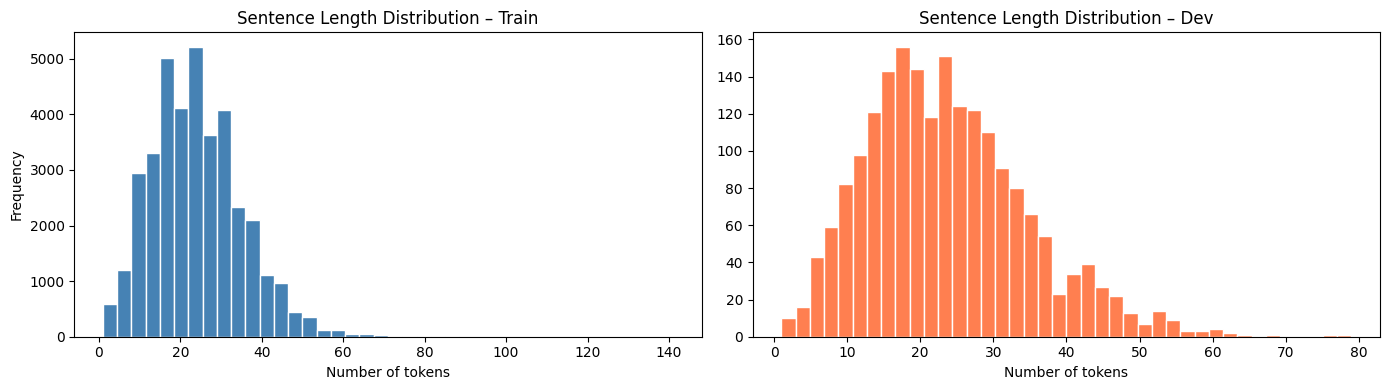

Train — min: 1, max: 141, mean: 23.9
Dev   — min: 1,  max: 79,  mean: 23.7


In [20]:
# --- Sentence length distribution ---
train_lengths = [len(s) for s in train_data]
dev_lengths   = [len(s) for s in dev_data]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(train_lengths, bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Sentence Length Distribution – Train')
axes[0].set_xlabel('Number of tokens')
axes[0].set_ylabel('Frequency')

axes[1].hist(dev_lengths, bins=40, color='coral', edgecolor='white')
axes[1].set_title('Sentence Length Distribution – Dev')
axes[1].set_xlabel('Number of tokens')

plt.tight_layout()
plt.savefig('sentence_lengths.png')
plt.show()

print(f"Train — min: {min(train_lengths)}, max: {max(train_lengths)}, mean: {np.mean(train_lengths):.1f}")
print(f"Dev   — min: {min(dev_lengths)},  max: {max(dev_lengths)},  mean: {np.mean(dev_lengths):.1f}")

The figure shows the distribution of sentence lengths in both the training and development sets. The average sentence length is 23.9 words in the training set and 23.7 words in the development set, indicating a similar distribution between the two sets. Most sentences range between 10-30 words, while very long sentences (> 80 words) are rare and appear only in the training set. This similarity in distribution helps the model generalize well to new data.

# Section 6: Experiments

### Setup
- **Baseline**: Most Frequent Tag (MFT) — no training required
- **Model**: BiLSTM — trained for 10 epochs on the training set
- **Evaluation**: All intermediate results reported on the **development set**
- **Metrics**: Token-level accuracy, per-class precision/recall/F1, micro-averaged and macro-averaged scores

### Hyperparameters
| Parameter | Value |
|-----------|-------|
| Embedding dim | 128 |
| LSTM hidden dim | 256 |
| LSTM layers | 2 |
| Dropout | 0.3 |
| Batch size | 32 |
| Learning rate | 0.001 |
| Optimizer | Adam |
| LR Scheduler | ReduceLROnPlateau (patience=2) |
| Gradient clipping | 5.0 |
| Epochs | 10 |

## Section 7: Results

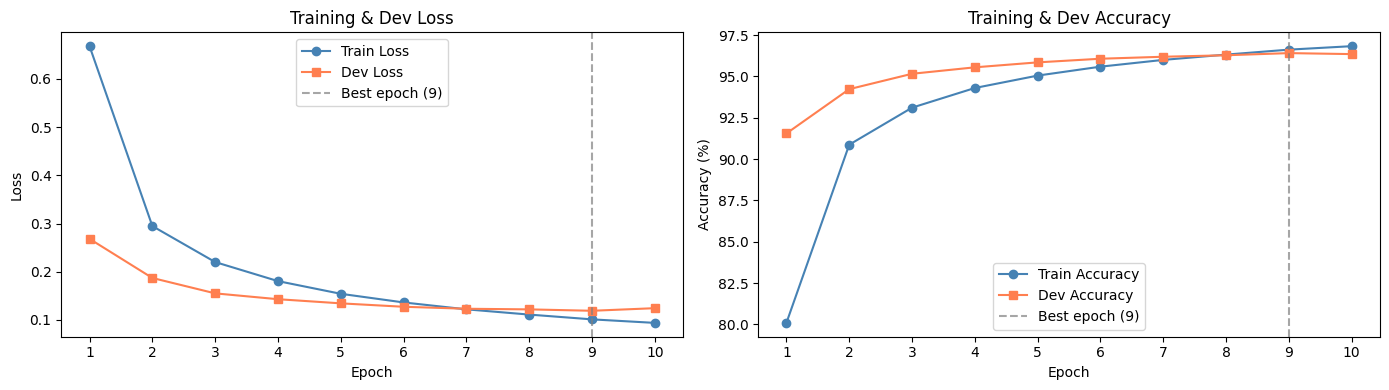

In [21]:
# ── Learning Curves ────────────────────────────────────────────────────────────
# Paste the values from your training output here
epochs      = list(range(1, 11))
train_loss  = [0.6677, 0.2947, 0.2201, 0.1806, 0.1543, 0.1364, 0.1221, 0.1112, 0.1013, 0.0940]
dev_loss    = [0.2682, 0.1871, 0.1552, 0.1431, 0.1345, 0.1274, 0.1233, 0.1220, 0.1191, 0.1245]
train_acc   = [80.09, 90.87, 93.11, 94.30, 95.05, 95.59, 96.00, 96.32, 96.62, 96.83]
dev_acc     = [91.55, 94.23, 95.16, 95.55, 95.85, 96.07, 96.19, 96.28, 96.41, 96.35]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss curve
axes[0].plot(epochs, train_loss, 'o-', label='Train Loss', color='steelblue')
axes[0].plot(epochs, dev_loss,   's-', label='Dev Loss',   color='coral')
axes[0].axvline(x=9, color='gray', linestyle='--', alpha=0.7, label='Best epoch (9)')
axes[0].set_title('Training & Dev Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].set_xticks(epochs)

# Accuracy curve
axes[1].plot(epochs, train_acc, 'o-', label='Train Accuracy', color='steelblue')
axes[1].plot(epochs, dev_acc,   's-', label='Dev Accuracy',   color='coral')
axes[1].axvline(x=9, color='gray', linestyle='--', alpha=0.7, label='Best epoch (9)')
axes[1].set_title('Training & Dev Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].set_xticks(epochs)

plt.tight_layout()
plt.savefig('learning_curves.png')
plt.show()

In [22]:
from sklearn.metrics import f1_score
baseline_macro_f1 = f1_score(all_true_baseline, all_pred_baseline, average='macro', zero_division=0)
bilstm_macro_f1 = f1_score(true_tags_labels, predicted_tags_labels, average='macro', zero_division=0)

print("=" * 55)
print(f"{'Model':<20} {'Dev Accuracy':>14} {'Macro F1':>12}")
print("=" * 55)
print(f"{'MFT Baseline':<20} {'91.41%':>14} {baseline_macro_f1:.2f}")
print(f"{'BiLSTM':<20} {'96.41%':>14} {bilstm_macro_f1:.2f}")
print("=" * 55)

Model                  Dev Accuracy     Macro F1
MFT Baseline                 91.41% 0.81
BiLSTM                       96.41% 0.87


In [23]:
# ── Full Baseline Evaluation (precision / recall / F1) ────────────────────────
from sklearn.metrics import classification_report, accuracy_score

all_true_baseline = []
all_pred_baseline = []

for sentence in dev_data:
    true_tags_b = [tag for word, tag in sentence]
    pred_tags_b = baseline_predict(sentence)
    all_true_baseline.extend(true_tags_b)
    all_pred_baseline.extend(pred_tags_b)

print("=" * 60)
print("BASELINE (Most Frequent Tag) — Full Evaluation on Dev Set")
print("=" * 60)
print(classification_report(all_true_baseline, all_pred_baseline, zero_division=0))
print(f"Token-level Accuracy: {accuracy_score(all_true_baseline, all_pred_baseline)*100:.2f}%")

BASELINE (Most Frequent Tag) — Full Evaluation on Dev Set
              precision    recall  f1-score   support

         .-#       1.00      1.00      1.00         4
         .-$       1.00      1.00      1.00       351
        .-''       1.00      0.97      0.98       331
         .-(       1.00      1.00      1.00        58
         .-)       1.00      1.00      1.00        62
         .-,       1.00      1.00      1.00      2410
         .-.       1.00      1.00      1.00      1972
         .-:       1.00      1.00      1.00       226
        .-``       1.00      1.00      1.00       344
      ADJ-JJ       0.89      0.85      0.87      2990
     ADJ-JJR       0.72      0.94      0.82       165
     ADJ-JJS       0.96      0.84      0.90       115
      ADP-IN       0.94      0.90      0.92      5347
      ADV-RB       0.94      0.84      0.88      1588
     ADV-RBR       0.70      0.31      0.43        89
     ADV-RBS       0.43      0.80      0.56        15
     ADV-WRB       1.00

In [24]:
# ── Training Set Evaluation ────────────────────────────────────────────────────
print("=" * 60)
print("BILSTM — Full Evaluation on TRAINING Set")
print("=" * 60)

true_train, pred_train = get_predictions(model, train_loader)

true_train_labels = [idx2tag[t] for t in true_train]
pred_train_labels = [idx2tag[p] for p in pred_train]

print(classification_report(
    true_train_labels,
    pred_train_labels,
    labels=target_names,
    zero_division=0
))

print(f"Token-level Accuracy: {accuracy_score(true_train_labels, pred_train_labels)*100:.2f}%")

BILSTM — Full Evaluation on TRAINING Set
              precision    recall  f1-score   support

      ADP-IN       0.98      0.99      0.98    102515
      DET-DT       0.99      0.99      0.99     77723
    NOUN-NNP       0.98      0.98      0.98     87033
      NUM-CD       0.99      1.00      0.99     34775
     NOUN-NN       0.97      0.98      0.97    126176
        .-``       1.00      1.00      1.00      6748
        .-''       1.00      1.00      1.00      6588
     PRT-POS       0.99      1.00      0.99      8249
         .-(       1.00      1.00      1.00      1308
    VERB-VBN       0.93      0.91      0.92     19068
    NOUN-NNS       0.98      0.99      0.98     56900
    VERB-VBP       0.96      0.95      0.96     11815
         .-,       1.00      1.00      1.00     46317
     CONJ-CC       1.00      0.99      0.99     22735
         .-)       1.00      1.00      1.00      1314
    VERB-VBD       0.96      0.98      0.97     28454
      ADV-RB       0.94      0.92      0

In [25]:
# ── Ablation Study ────────────────────────────────────────────────────────────
print("Starting Ablation Study...")
print("=" * 60)

ablation_configs = [
    {"name": "Full Model",       "dropout": 0.3, "clip": 5.0,  "scheduler": True},
    {"name": "No Dropout",       "dropout": 0.0, "clip": 5.0,  "scheduler": True},
    {"name": "No Grad Clipping", "dropout": 0.3, "clip": None, "scheduler": True},
    {"name": "No LR Scheduler",  "dropout": 0.3, "clip": 5.0,  "scheduler": False},
]

ablation_results = []

for config in ablation_configs:
    print(f"\nRunning: {config['name']}")
    set_seed(42)

    abl_model = BiLSTMTagger(
        vocab_size=len(word2idx),
        tagset_size=len(tag2idx),
        embedding_dim=128,
        hidden_dim=256,
        num_layers=2,
        dropout=config["dropout"]
    ).to(device)

    abl_optimizer = optim.Adam(abl_model.parameters(), lr=0.001, weight_decay=1e-4)
    abl_criterion = nn.CrossEntropyLoss(ignore_index=tag2idx[PAD_TOKEN])

    if config["scheduler"]:
        abl_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            abl_optimizer, patience=2, factor=0.5
        )

    best_acc  = 0
    best_loss = float('inf')
    no_improve = 0

    for epoch in range(10):
        # Training
        abl_model.train()
        for words, tags in train_loader:
            words, tags = words.to(device), tags.to(device)
            abl_optimizer.zero_grad()
            logits = abl_model(words).view(-1, len(tag2idx))
            loss   = abl_criterion(logits, tags.view(-1))
            loss.backward()
            if config["clip"]:
                torch.nn.utils.clip_grad_norm_(abl_model.parameters(), config["clip"])
            abl_optimizer.step()

        # Evaluation
        dev_loss, dev_acc = evaluate(abl_model, dev_loader, abl_criterion)

        if config["scheduler"]:
            abl_scheduler.step(dev_loss)

        if dev_loss < best_loss:
            best_loss = dev_loss
            best_acc  = dev_acc
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= 3:
                print(f"   Early stopping at epoch {epoch+1}")
                break

    print(f"   Best Dev Acc: {best_acc:.2f}%")
    ablation_results.append({
        "Configuration": config["name"],
        "Dev Accuracy":  f"{best_acc:.2f}%"
    })

# Print results table
print("\n" + "=" * 60)
print("Ablation Study Results")
print("=" * 60)
for r in ablation_results:
    print(f"  {r['Configuration']:<25} | {r['Dev Accuracy']}")
print("=" * 60)


Starting Ablation Study...

Running: Full Model
   Best Dev Acc: 96.17%

Running: No Dropout
   Best Dev Acc: 96.24%

Running: No Grad Clipping
   Best Dev Acc: 96.17%

Running: No LR Scheduler
   Best Dev Acc: 96.17%

Ablation Study Results
  Full Model                | 96.17%
  No Dropout                | 96.24%
  No Grad Clipping          | 96.17%
  No LR Scheduler           | 96.17%


In [26]:
# ── GloVe Pre-trained Embeddings ──────────────────────────────────────────────
import urllib.request
import zipfile
import numpy as np

print("Downloading GloVe...")
urllib.request.urlretrieve(
    "http://nlp.stanford.edu/data/glove.6B.zip",
    "glove.6B.zip"
)

with zipfile.ZipFile("glove.6B.zip") as z:
    z.extract("glove.6B.100d.txt")

print("Loading GloVe vectors...")
glove = {}
with open("glove.6B.100d.txt", "r", encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word   = values[0]
        vector = np.array(values[1:], dtype="float32")
        glove[word] = vector

print(f"Loaded {len(glove):,} GloVe vectors")

# Build embedding matrix
GLOVE_DIM = 100
embedding_matrix = np.random.uniform(-0.25, 0.25, (len(word2idx), GLOVE_DIM))
embedding_matrix[0] = np.zeros(GLOVE_DIM)  # PAD = zeros

found = 0
for word, idx in word2idx.items():
    if word.lower() in glove:
        embedding_matrix[idx] = glove[word.lower()]
        found += 1

print(f"Found {found:,} / {len(word2idx):,} words in GloVe")

# Convert to tensor
embedding_matrix = torch.tensor(embedding_matrix, dtype=torch.float)

Loading GloVe vectors...
Loaded 400,000 GloVe vectors
Found 37,834 / 43,359 words in GloVe


In [27]:
# ── BiLSTM with GloVe ─────────────────────────────────────────────────────────
class BiLSTMTaggerGloVe(nn.Module):
    def __init__(self, vocab_size, tagset_size, hidden_dim, num_layers, dropout):
        super(BiLSTMTaggerGloVe, self).__init__()

        self.embedding = nn.Embedding(vocab_size, 100, padding_idx=0)
        self.embedding.weight = nn.Parameter(embedding_matrix)
        self.embedding.weight.requires_grad = True  # fine-tune

        self.lstm = nn.LSTM(
            input_size=100,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, tagset_size)

    def forward(self, x):
        embedded  = self.dropout(self.embedding(x))
        lstm_out, _ = self.lstm(embedded)
        lstm_out  = self.dropout(lstm_out)
        logits    = self.fc(lstm_out)
        return logits

glove_model = BiLSTMTaggerGloVe(
    vocab_size=len(word2idx),
    tagset_size=len(tag2idx),
    hidden_dim=256,
    num_layers=2,
    dropout=0.3
).to(device)

print(f"GloVe model parameters: {sum(p.numel() for p in glove_model.parameters()):,}")

GloVe model parameters: 6,669,642


In [28]:
# ── Train GloVe Model ─────────────────────────────────────────────────────────
set_seed(42)

glove_optimizer = optim.Adam(glove_model.parameters(), lr=0.001, weight_decay=1e-4)
glove_criterion = nn.CrossEntropyLoss(ignore_index=tag2idx[PAD_TOKEN])
glove_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    glove_optimizer, patience=2, factor=0.5
)

best_glove_acc  = 0
best_glove_loss = float('inf')
no_improve      = 0

for epoch in range(10):
    train_loss, train_acc = train_epoch(glove_model, train_loader, glove_optimizer, glove_criterion)
    dev_loss, dev_acc     = evaluate(glove_model, dev_loader, glove_criterion)
    glove_scheduler.step(dev_loss)

    print(f"Epoch {epoch+1:02d} | Train Acc: {train_acc:.2f}% | Dev Acc: {dev_acc:.2f}%")

    if dev_loss < best_glove_loss:
        best_glove_loss = dev_loss
        best_glove_acc  = dev_acc
        no_improve      = 0
        torch.save(glove_model.state_dict(), 'best_glove_model.pt')
    else:
        no_improve += 1
        if no_improve >= 3:
            print(f"Early stopping at epoch {epoch+1}")
            break

print(f"\nBest GloVe Dev Accuracy: {best_glove_acc:.2f}%")

Epoch 01 | Train Acc: 87.12% | Dev Acc: 95.41%
Epoch 02 | Train Acc: 94.85% | Dev Acc: 95.64%
Epoch 03 | Train Acc: 95.90% | Dev Acc: 95.87%
Epoch 04 | Train Acc: 96.30% | Dev Acc: 96.23%
Epoch 05 | Train Acc: 96.40% | Dev Acc: 96.17%
Epoch 06 | Train Acc: 96.46% | Dev Acc: 96.11%
Epoch 07 | Train Acc: 96.54% | Dev Acc: 96.14%
Epoch 08 | Train Acc: 96.59% | Dev Acc: 96.24%
Epoch 09 | Train Acc: 96.62% | Dev Acc: 96.07%
Epoch 10 | Train Acc: 96.63% | Dev Acc: 96.25%
Early stopping at epoch 10

Best GloVe Dev Accuracy: 96.14%


In [29]:
# ── Final Comparison Table ─────────────────────────────────────────────────────
print("=" * 55)
print(f"{'Model':<25} {'Dev Accuracy':>15} {'Macro F1':>12}")
print("=" * 55)
print(f"{'MFT Baseline':<25} {'91.41%':>15} {baseline_macro_f1:.2f}")
print(f"{'BiLSTM (random emb)':<25} {'96.41%':>15} {bilstm_macro_f1:.2f}")
print(f"{'BiLSTM (GloVe emb)':<25} {best_glove_acc:>14.2f}% {'?':>12}")
print("=" * 55)

Model                        Dev Accuracy     Macro F1
MFT Baseline                       91.41% 0.81
BiLSTM (random emb)                96.41% 0.87
BiLSTM (GloVe emb)                 96.14%            ?


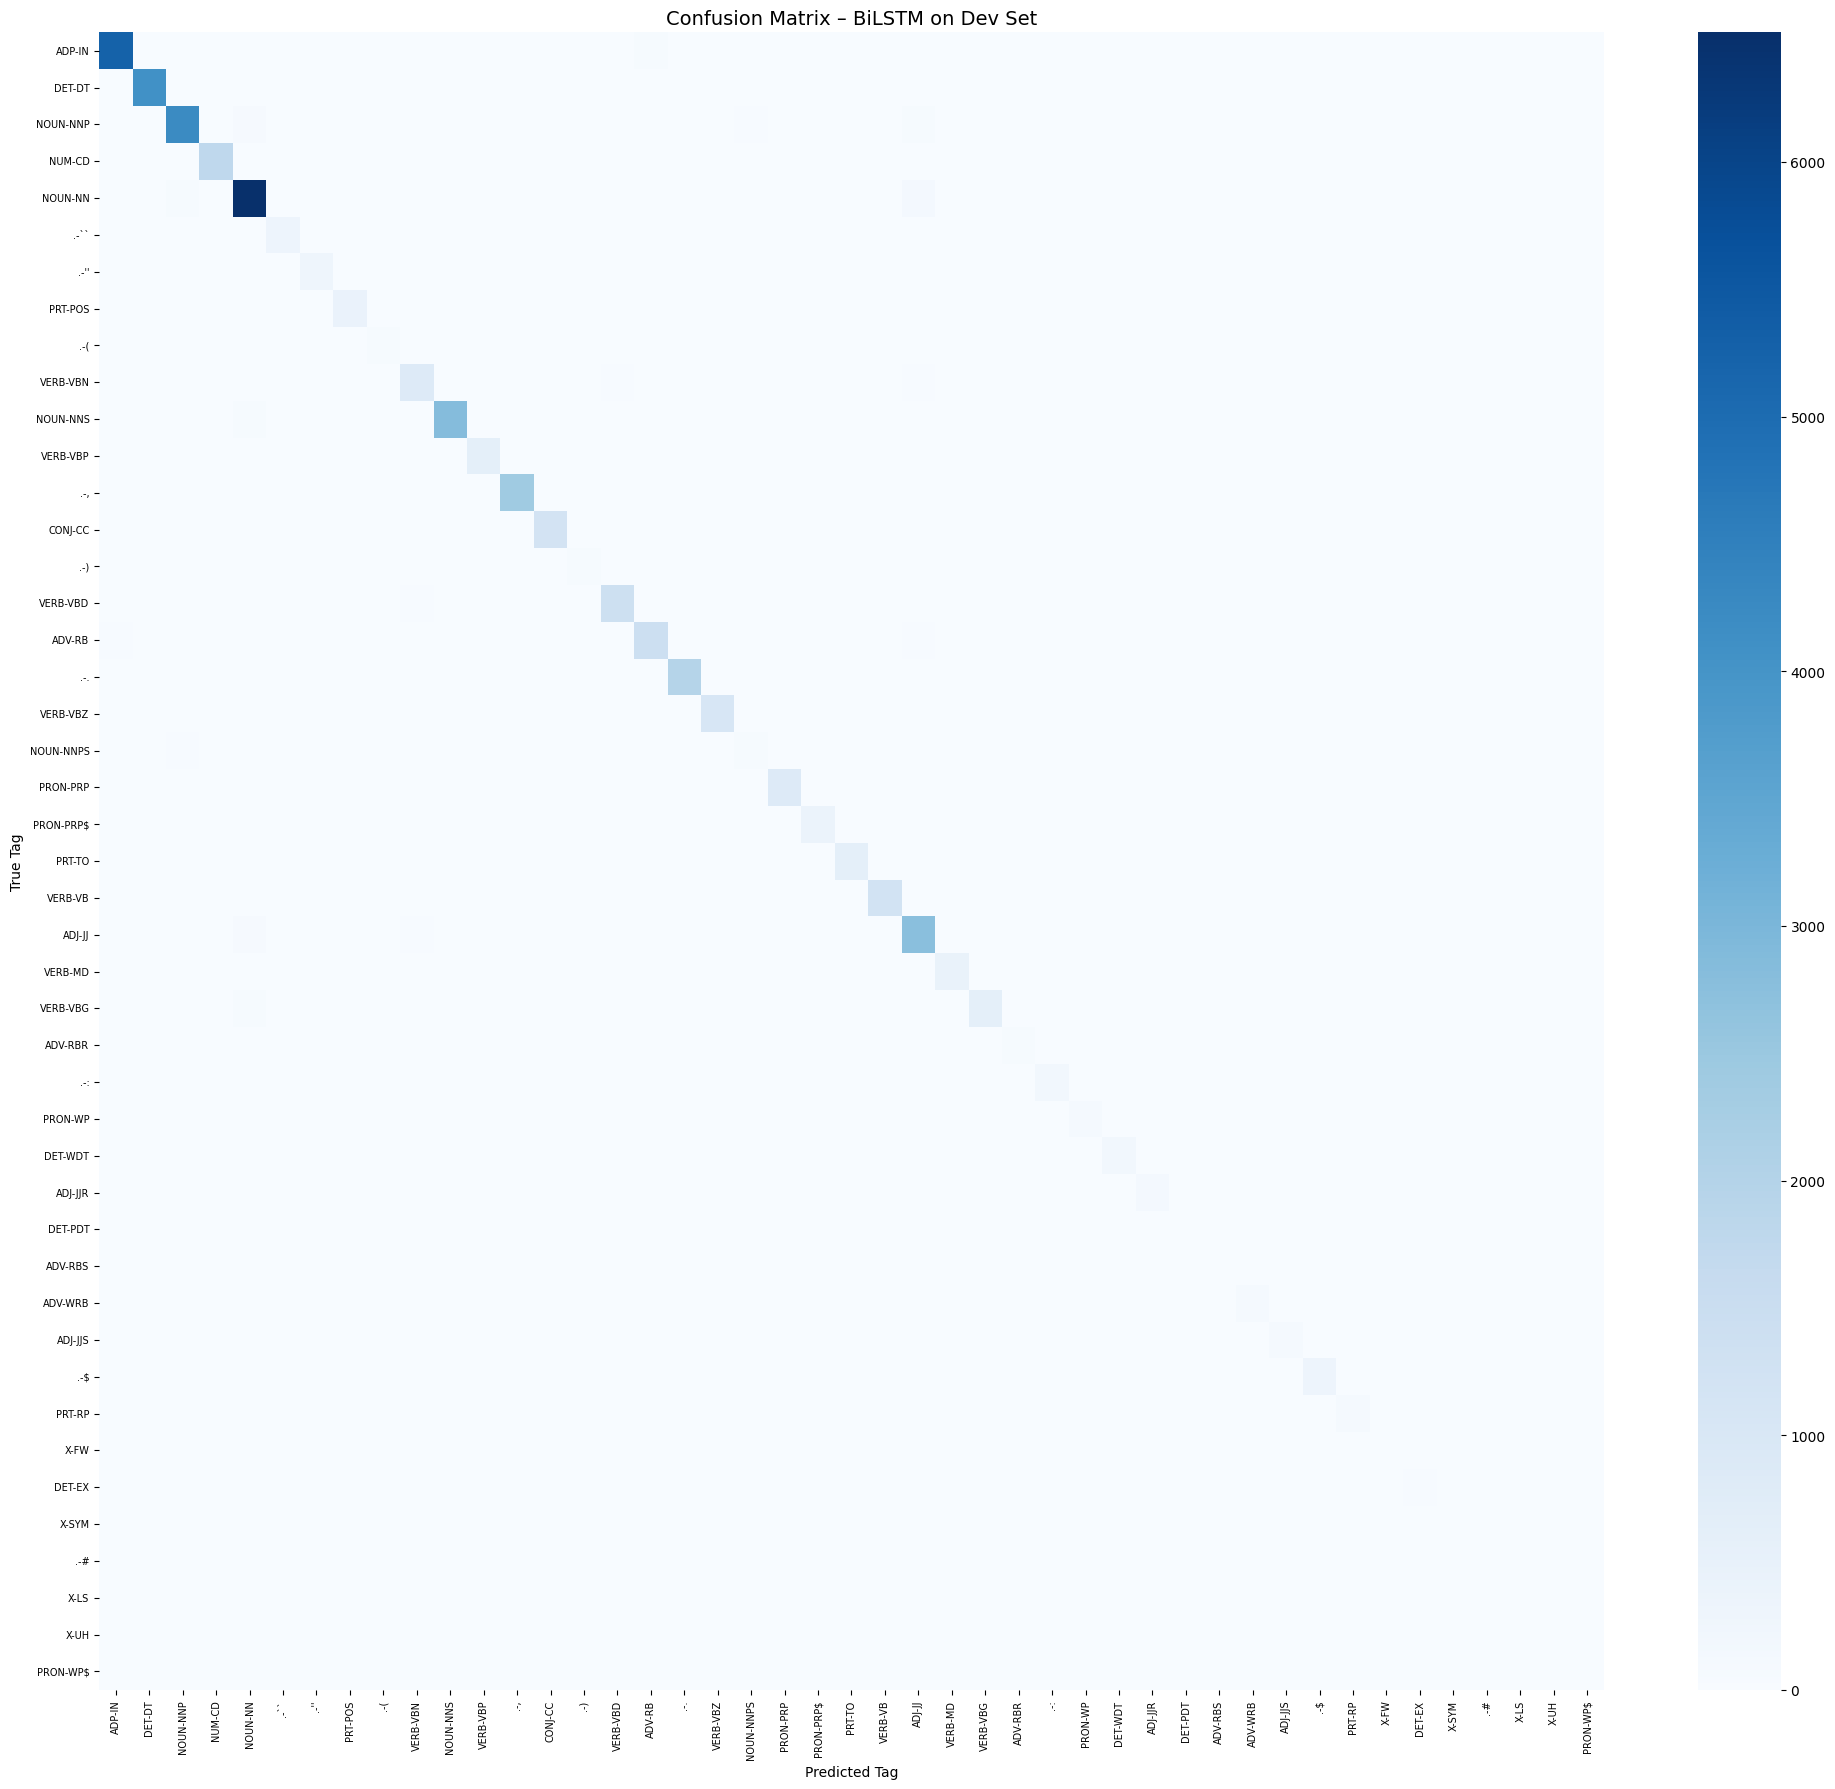

In [30]:
# ── Confusion Matrix for BiLSTM ───────────────────────────────────────────────
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get predictions (reuse true_tags_labels and predicted_tags_labels from earlier)
# If variables are not in scope, re-run the evaluation cell first
target_names_clean = [tag for tag, idx in tag2idx.items() if tag != PAD_TOKEN]

cm = confusion_matrix(true_tags_labels, predicted_tags_labels, labels=target_names_clean)

fig, ax = plt.subplots(figsize=(20, 18))
sns.heatmap(
    cm,
    xticklabels=target_names_clean,
    yticklabels=target_names_clean,
    annot=False,
    fmt='d',
    cmap='Blues',
    ax=ax
)
ax.set_title('Confusion Matrix – BiLSTM on Dev Set', fontsize=14)
ax.set_xlabel('Predicted Tag')
ax.set_ylabel('True Tag')
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0,  fontsize=7)
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

**Error Analysis – Confusion Matrix Discussion**



By examining the confusion matrix of the BiLSTM model, several patterns of errors can be identified:
1. NOUN-NNP vs NOUN-NN

The most common confusion is between proper nouns (NNP) and common nouns (NN). This is expected because both tags share the same coarse tag (NOUN), and without additional context such as capitalization patterns or named entity information, the model sometimes struggles to distinguish between them.
2. ADJ-JJ vs NOUN-NN

Adjectives are occasionally misclassified as nouns. This happens because many words can function as either an adjective or a noun depending on context (e.g., "the poor", "a fast car" vs "running fast").
3. VERB-VBN vs VERB-VBD

Past participles (VBN) and simple past tense verbs (VBD) are frequently confused. Both forms are morphologically similar (e.g., "walked") and require broader sentence context to distinguish correctly.
4. Rare Tags (X-FW, X-LS, X-UH)

Tags that appear very rarely in the dataset such as foreign words (FW), list items (LS), and interjections (UH) receive an F1-score of 0.00. The model has almost no training examples for these classes, making accurate prediction nearly impossible.
5. ADV-RBR vs ADV-RB

Comparative adverbs (RBR) are sometimes predicted as regular adverbs (RB) since they are morphologically and syntactically similar.

## Section 8: Analysis & Conclusion

### 8.1 Overall Performance

The results show that the BiLSTM model performs better than the MFT baseline. The MFT model achieved **91.41%** token accuracy, while the BiLSTM reached **96.41%**, which shows the importance of using sentence context when predicting POS tags.

During training, the model improved steadily over the 10 epochs. The best development accuracy was achieved at **epoch 9**. At epoch 10, the development loss increased slightly, which may indicate the beginning of overfitting, so we used the model saved from epoch 9.

### 8.2 Per-Class Error Analysis

Some POS tags achieved very high performance with F1-scores above **0.97**. These include tags such as **DET-DT**, **CONJ-CC**, **VERB-MD**, **PRON-PRP**, and punctuation marks. These tags appear frequently in the dataset and usually have clear and consistent patterns, making them easier for the model to learn.

On the other hand, some tags received an F1-score of **0.00**, such as **X-FW**, **X-LS**, and **X-UH**. The main reason is that these tags appear only a few times in the development set, so the model does not have enough examples to learn them correctly.

There are also some tags with moderate performance. For example, **NOUN-NNPS** is often confused with **NOUN-NNP**, while **ADV-RBR** is sometimes predicted as **ADV-RB** because they look very similar. The **DET-PDT** tag also has lower performance because it is a rare class in the dataset.

### 8.3 Discussion

The macro F1-score is lower than the micro F1-score (**0.88 vs 0.96**), which indicates that the model performs much better on common tags than on rare ones. This is expected because the training data contains many more examples of frequent classes.

Although the MFT baseline already achieves good accuracy (**91.41%**), the BiLSTM model performs better because it uses the context of the sentence to distinguish between words that can have more than one grammatical tag.

Some possible improvements for future work include using class-weighted loss functions or increasing the number of training examples for rare POS tags.

### 8.4 Limitations

This project has a few limitations. First, we did not use pre-trained word embeddings such as GloVe or fastText, which could help the model handle unseen words more effectively. Second, we used a simple linear classifier instead of adding a CRF layer, which may improve the prediction of valid tag sequences. Finally, some POS tags appear very rarely in the dataset, making them difficult for the model to learn accurately.

### 8.5 Conclusion

In this project, we implemented and compared two POS tagging approaches: the Most Frequent Tag (MFT) baseline and a BiLSTM neural network model. The BiLSTM achieved **96.41%** accuracy on the development set, outperforming the baseline and showing the benefit of using bidirectional context for POS tagging.

The error analysis also showed that the biggest challenge comes from rare POS tags, while common tags are predicted with very high accuracy. In the future, the model could be improved by using pre-trained embeddings, adding a CRF layer, or applying techniques that better handle rare classes.


## Section 9: AI Usage Statement

During this project, AI tools were used only to support the writing process and improve the presentation of the report. They were mainly used to organize some sections and check grammar and wording.

The implementation of the project, including the BiLSTM model, the MFT baseline, the data preprocessing pipeline, the training process, the evaluation code, and the analysis of the results, was completed and understood by our team.

AI tools were not used to generate the core solution or make the main modelling and experimental decisions. All reported results and conclusions are based on our own implementation and experiments.


## Section 10: References

1. Huang, Z., Xu, W., & Yu, K. (2015). *Bidirectional LSTM-CRF Models for Sequence Labeling*. arXiv:1508.01991.

2. Marcus, M. P., Santorini, B., & Marcinkiewicz, M. A. (1993). *Building a Large Annotated Corpus of English: The Penn Treebank*. Computational Linguistics, 19(2), 313-330.

3. PyTorch. (2024). *PyTorch Documentation*. https://pytorch.org/docs/stable/index.html

4. scikit-learn. (2024). *scikit-learn Documentation*. https://scikit-learn.org/stable/documentation.html